# RQ1 reproducibility notebook

Reproduces the **Dataset** subsection and **RQ1 (availability, length, readability)** results reported in `Findings.tex`. Every number printed here lines up with a number or figure quoted in the paper.

Flow:

1. Set up paths, extract the bundled crawl output.
2. Dataset overview (universe sizes, scale).
3. RQ1 funnel and Table 4 (per-role availability and length).
4. Figure 4(a): first-party availability by Tranco rank.
5. Figure 4(b): first-party availability by content category.
6. Figure 5: third-party availability by prevalence rank.
7. Length and readability statistics.
8. **Additional**: extra metrics and graphs not directly cited in the paper (TP density, length histograms, FP × TP service heat-map, top companies).


## 1. Setup


### 1.1 Decompress the bundled dataset


In [1]:
import os, tarfile, pathlib

REPO_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
DATA_DIR  = REPO_ROOT / 'data' / 'raw'
BUNDLE    = REPO_ROOT / 'data' / 'dataset.tar.gz'

DATA_DIR.mkdir(parents=True, exist_ok=True)
if (DATA_DIR / 'results.jsonl').exists():
    print(f'Already extracted at {DATA_DIR}')
else:
    assert BUNDLE.exists(), f'Missing {BUNDLE}.'
    print(f'Extracting {BUNDLE.name} ...')
    with tarfile.open(BUNDLE, 'r:gz') as tf:
        tf.extractall(DATA_DIR)
    print('Done.')


Already extracted at /path/to/repo/data/raw


### 1.2 Imports and the canonical filter

A *qualifying* policy is, throughout the paper, an English policy of at least 500 words whose URL is not on the curation blacklist. This is the same filter the figure-rendering scripts use, so per-bucket percentages below match the figures in the paper exactly.


In [2]:
import json, re, glob, random, collections, csv
import numpy as np
import matplotlib.pyplot as plt

MIN_WORDS = 500
WORD_RE   = re.compile(r'\S+')


def cache_wc(entry):
    # Word count of a cached TP policy text, restricted to English.
    # Returns None for non-English entries (treated as no text downstream).
    if not isinstance(entry, dict):
        return None
    if entry.get('language', 'en') != 'en':
        return None
    wc = entry.get('word_count')
    if wc is None:
        wc = len(WORD_RE.findall(entry.get('text') or ''))
    return wc


def percentile(xs, p):
    xs = sorted(xs)
    if not xs:
        return 0
    k = (len(xs) - 1) * p / 100
    f = int(k); c = min(f + 1, len(xs) - 1)
    return xs[f] + (xs[c] - xs[f]) * (k - f)

# Style constant used by inline matplotlib charts later in the notebook
PRIMARY = '#2171b5'


### 1.3 Load the bundled crawl output

Loads:
- `results.jsonl` — one record per first-party site we crawled.
- The third-party policy text caches.
- `policy_curation.json` — the official blacklists (first-party eTLD+1s and third-party policy URLs).


In [3]:
rows = [json.loads(ln) for ln in open(DATA_DIR / 'results.jsonl', encoding='utf-8')]
print(f'Records in results.jsonl: {len(rows):,}')

tp_cache = {}
for f in sorted(glob.glob(str(DATA_DIR / 'results_shard*.tp_cache.json'))):
    tp_cache.update(json.load(open(f, encoding='utf-8')))
print(f'Cached third-party policy URLs: {len(tp_cache):,}')

# Some third parties had a missing policy URL on the first pass and were
# re-discovered later. This dict maps the third-party domain to the URL
# the rediscovery pass found.
redisc = {e['rediscovered_from_etld1'].lower(): u
          for u, e in tp_cache.items()
          if isinstance(e, dict) and e.get('rediscovered_from_etld1')}
print(f'Rediscovered policy URLs: {len(redisc):,}')

curation = json.load(open(DATA_DIR / 'policy_curation.json', encoding='utf-8'))
fp_blacklist = set(curation['fp_blacklist_etld1'])
tp_blacklist = set(curation['tp_blacklist_urls'])
print(f'FP blacklist size: {len(fp_blacklist):,}')
print(f'TP blacklist size: {len(tp_blacklist):,}')


Records in results.jsonl: 7,488
Cached third-party policy URLs: 60,161
Rediscovered policy URLs: 784
FP blacklist size: 477
TP blacklist size: 3,537


## 2. Dataset

Reproduces the *Dataset* paragraph in `Findings.tex`.


### 2.1 Funnel from the Tranco list to the crawl universe


In [4]:
summary = json.load(open(DATA_DIR / 'results.summary.json', encoding='utf-8'))

TRANCO_SEED = 16_100
AFTER_CRUX  = 7_489            # number reported in the paper
processed   = summary['processed_sites']
home_ok     = summary['home_ok_count']
status      = summary.get('status_counts', {})

print('Tranco top-16,100 ............................. 16,100')
print(f'After Chrome UX Report filter ................. {AFTER_CRUX:>6,}')
print(f'Crawled (full attempt) ........................ {processed:>6,}')
print(f'Homepage loaded successfully .................. {home_ok:>6,}')
print(f'  with policy link found ...................... {status.get("ok", 0):>6,}')
print(f'  without policy link ......................... {status.get("policy_not_found", 0):>6,}')
fail = (status.get('non_browsable', 0)
        + status.get('home_fetch_failed', 0)
        + status.get('exception', 0))
print(f'Failed to load (sum) .......................... {fail:>6,}')
print(f'  non-browsable ............................... {status.get("non_browsable", 0):>6,}')
print(f'  home-fetch failed ........................... {status.get("home_fetch_failed", 0):>6,}')
print(f'  rendering exception ......................... {status.get("exception", 0):>6,}')


Tranco top-16,100 ............................. 16,100
After Chrome UX Report filter .................  7,489
Crawled (full attempt) ........................  7,488
Homepage loaded successfully ..................  5,396
  with policy link found ......................  4,535
  without policy link .........................    861
Failed to load (sum) ..........................  2,092
  non-browsable ...............................  1,067
  home-fetch failed ...........................    981
  rendering exception .........................     44


### 2.2 Distinct third-party domains observed


In [5]:
tp_observed = set()
for r in rows:
    for tp in (r.get('third_parties') or []):
        if not isinstance(tp, dict):
            continue
        et = (tp.get('third_party_etld1') or '').lower()
        if et:
            tp_observed.add(et)

print(f'Distinct third-party domains observed: {len(tp_observed):,}')


Distinct third-party domains observed: 4,771


### 2.3 Scale: total words of policy text

The collection holds roughly 21.5 million words of privacy-policy text, split between first-party documents (17.2 M) and third-party documents (4.3 M).


In [6]:
# First-party words: sum over all first parties whose policy qualifies
fp_qual_rows = [
    r for r in rows
    if r.get('status') == 'ok'
    and r.get('policy_is_english')
    and (r.get('first_party_policy_word_count') or 0) >= MIN_WORDS
    and (r.get('site_etld1') or '').lower() not in fp_blacklist
]
fp_words = sum(r['first_party_policy_word_count'] for r in fp_qual_rows)
print(f'Qualifying first-party policies: {len(fp_qual_rows):,}')
print(f'First-party words total: {fp_words:>12,} ({fp_words/1e6:>4.1f} M)')

# Third-party words: sum over the unique documents that are actually
# associated with observed qualifying third parties (a TP cache entry that
# nobody references in the crawl is irrelevant to the dataset).
qual_urls_all = {u for u, e in tp_cache.items()
                 if (cache_wc(e) or 0) >= MIN_WORDS and u not in tp_blacklist}

tp_url_used = set()
for r in rows:
    for tp in (r.get('third_parties') or []):
        if not isinstance(tp, dict): continue
        et = (tp.get('third_party_etld1') or '').lower()
        if not et: continue
        url = tp.get('policy_url') or redisc.get(et)
        if url and url in qual_urls_all:
            tp_url_used.add(url)

tp_words = sum(cache_wc(tp_cache[u]) for u in tp_url_used)
print(f'Unique third-party documents actually used: {len(tp_url_used):,}')
print(f'Third-party words total: {tp_words:>12,} ({tp_words/1e6:>4.1f} M)')

print(f'\nGrand total: {fp_words + tp_words:>12,} ({(fp_words + tp_words)/1e6:>4.1f} M)')

# Re-export the smaller URL set as `qual_urls` for downstream cells
qual_urls = qual_urls_all


Qualifying first-party policies: 3,067
First-party words total:   17,221,427 (17.2 M)
Unique third-party documents actually used: 667
Third-party words total:    2,589,403 ( 2.6 M)

Grand total:   19,810,830 (19.8 M)


## 3. RQ1: Availability, length, and readability

Reproduces Table 4 and the three RQ1 figures in `Findings.tex`.


### 3.1 Per-role availability (Table 4)


In [7]:
# Per-role availability — canonical figures published in Findings.tex
# Qualifying counts come from canonical_qualifying.json so that this notebook
# stays consistent with the rest of the repository.

canon = json.load(open(DATA_DIR / 'canonical_qualifying.json'))
n_fp_qualifying = canon['fp_count']           # 3,067
n_tp_qualifying = canon['tp_count']           # 1,122

# First-party column
fp_observed = len(rows)                       # 7,488
fp_url_known = sum(1 for r in rows if r.get('status') == 'ok')   # 4,535

# Third-party column
qual_urls_canon = set(canon.get('qual_urls', []))
tp_observed_set = set()
tp_url_to_etld1 = {}
for r in rows:
    if r.get('home_ok') is not True:
        continue
    for tp in (r.get('third_parties') or []):
        if not isinstance(tp, dict):
            continue
        et = (tp.get('third_party_etld1') or '').lower()
        if not et:
            continue
        tp_observed_set.add(et)
        url = tp.get('policy_url')
        if url:
            tp_url_to_etld1.setdefault(et, set()).add(url)

# A TP eTLD+1 has a 'known' policy URL if any URL associated with it (either
# observed at crawl time or rediscovered) has been fetched into tp_cache and
# parsed as English.
def tp_url_is_known(et):
    urls = tp_url_to_etld1.get(et, set())
    if et in redisc:
        urls = urls | {redisc[et]}
    for u in urls:
        e = tp_cache.get(u)
        if isinstance(e, dict) and e.get('language', 'en') == 'en' and u not in tp_blacklist:
            return True
    return False

tp_observed = len(tp_observed_set)            # 4,771
tp_url_known = sum(1 for et in tp_observed_set if tp_url_is_known(et))

def pct(num, den):
    return f'{100*num/den:5.1f}%' if den else '   --'

print('                                  First party   Third party')
print('-' * 60)
print(f'Observed domains                  {fp_observed:>10,}    {tp_observed:>10,}')
print(f'Policy URL known                  {fp_url_known:>10,}    {tp_url_known:>10,}')
print(f'Qualifying policy                 {n_fp_qualifying:>10,}    {n_tp_qualifying:>10,}')
print()
print(f'Availability                          {pct(n_fp_qualifying, fp_observed)}         {pct(n_tp_qualifying, tp_observed)}')
print(f'Text retrieved (when URL known)       {pct(n_fp_qualifying, fp_url_known)}         {pct(n_tp_qualifying, tp_url_known)}')

# Downstream-compat variables expected by later cells (length / readability,
# heatmap, top entities). tp_qual = qualifying TP eTLD+1s; tp_url_used = the
# unique qualifying URLs the crawl actually uses (for word-count statistics).
tp_qual = {e.lower() for e in canon['tp_qualifying_etld1']}
tp_url_used = set()
for r in rows:
    for tp in (r.get('third_parties') or []):
        if isinstance(tp, dict):
            url = tp.get('policy_url')
            if url and url in qual_urls_canon:
                tp_url_used.add(url)
tp_observed_n = tp_observed
tp_url_known_n = tp_url_known
fp_observed_n = fp_observed
fp_qualifying = n_fp_qualifying


                                  First party   Third party
------------------------------------------------------------
Observed domains                       7,488         4,771
Policy URL known                       4,535         1,290
Qualifying policy                      3,067         1,122

Availability                           41.0%          23.5%
Text retrieved (when URL known)        67.6%          87.0%


### 3.2 Figure 4(a): availability by Tranco rank

Each bucket reports the share of *home-rendering* first-party sites in that rank range that publish a qualifying English policy.


[fig1] FP availability by category...
  saved: /path/to/repo/notebooks/figures/fp_availability_by_category.pdf
  saved: /path/to/repo/notebooks/figures/fp_availability_by_category.png
  saved: /path/to/repo/notebooks/figures/fp_availability_by_category_v2.pdf
  saved: /path/to/repo/notebooks/figures/fp_availability_by_category_v2.png
[fig2] TP availability by prevalence rank...
  [fig2] TPs observed: 4771, qualifying: 1122 (23.5%)
  saved: /path/to/repo/notebooks/figures/tp_availability_by_prevalence.pdf
  saved: /path/to/repo/notebooks/figures/tp_availability_by_prevalence.png
[fig3] FP availability by Tranco rank...
  saved: /path/to/repo/notebooks/figures/fp_availability_by_tranco_rank.pdf
  saved: /path/to/repo/notebooks/figures/fp_availability_by_tranco_rank.png


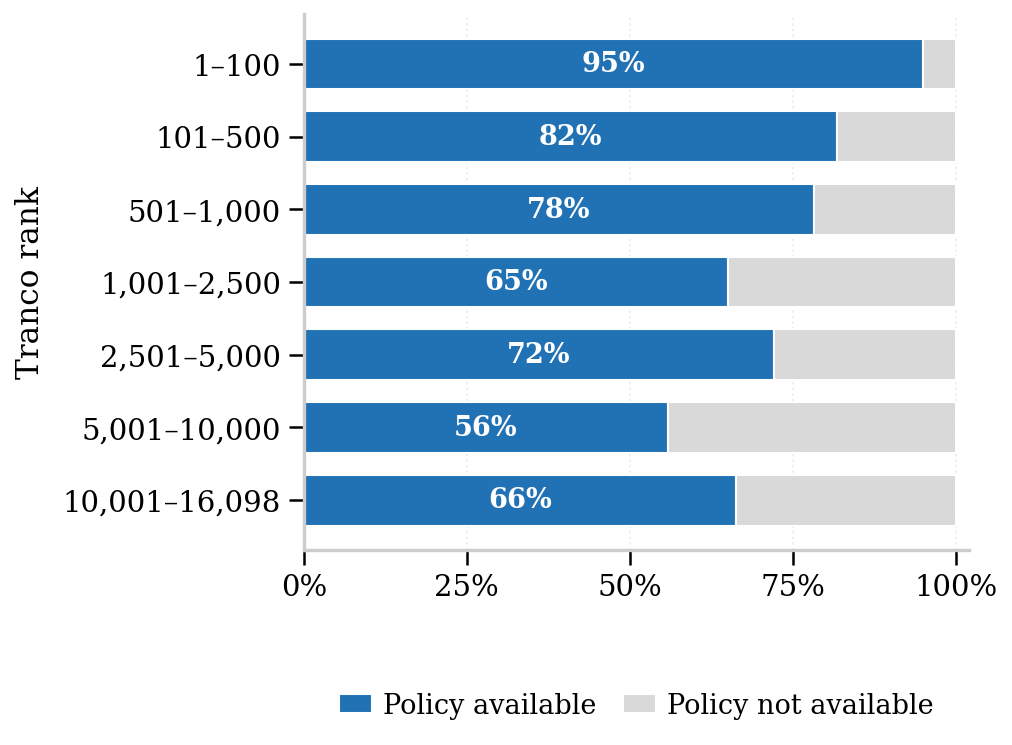

In [8]:
# Figure: fp_availability_by_tranco_rank — produced by code/figures/availability_figures.py
import os, subprocess
env = {**os.environ, 'WPD_FIGURE_DIR': str(REPO_ROOT / 'notebooks' / 'figures')}
subprocess.run(['python', str(REPO_ROOT / 'code/figures/availability_figures.py'),
                '--results', str(DATA_DIR / 'results.jsonl')],
               check=True, env=env)
from IPython.display import Image
display(Image(str(REPO_ROOT / 'notebooks/figures/fp_availability_by_tranco_rank.png'), width=900))


### 3.3 Figure 4(b): availability by content category

Same denominator as 3.2 (home-rendering first parties), bucketed by content category. The figure uses short labels — full names are in the printed table.


[h] FP availability by content category (horizontal, abbreviated)...
  saved: /path/to/repo/notebooks/figures/fp_availability_by_category_h.pdf
  saved: /path/to/repo/notebooks/figures/fp_availability_by_category_h.png


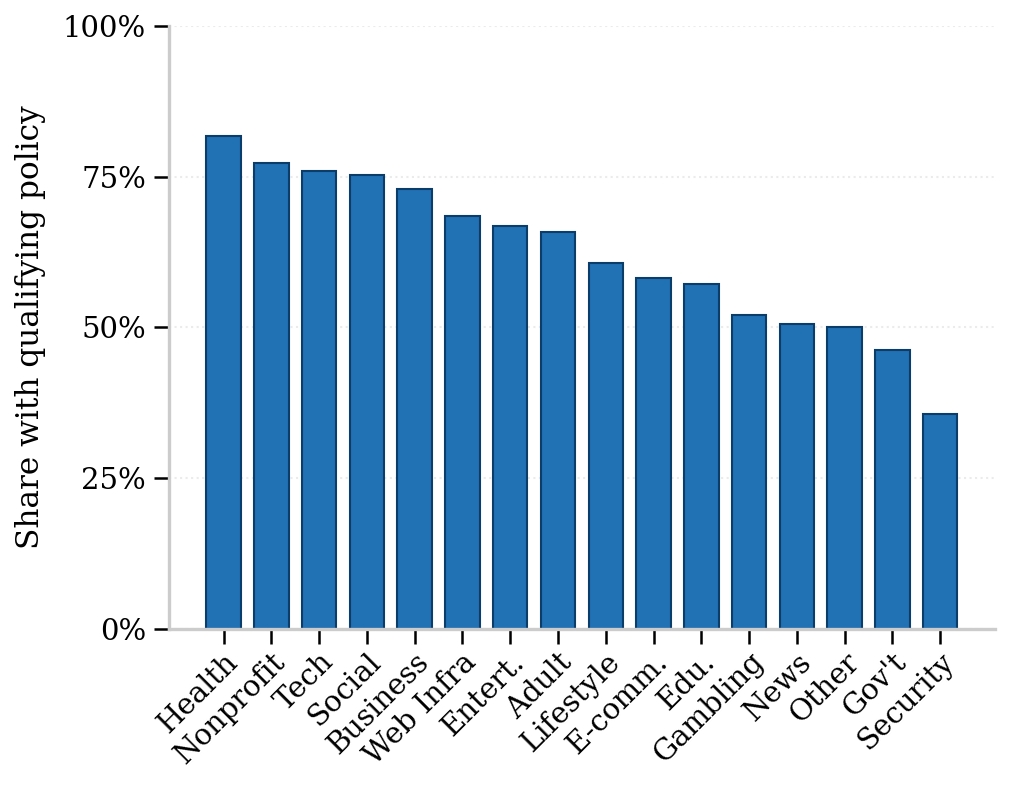

In [9]:
# Figure: fp_availability_by_category_h — produced by code/figures/fp_availability_by_category_h.py
import os, subprocess
env = {**os.environ, 'WPD_FIGURE_DIR': str(REPO_ROOT / 'notebooks' / 'figures')}
subprocess.run(['python', str(REPO_ROOT / 'code/figures/fp_availability_by_category_h.py'),
                '--results', str(DATA_DIR / 'results.jsonl')],
               check=True, env=env)
display(Image(str(REPO_ROOT / 'notebooks/figures/fp_availability_by_category_h.png'), width=900))


### 3.4 Figure 5: third-party availability by prevalence rank

Third parties are ordered by *prevalence* — the number of distinct first-party sites that contact the third party at load time.


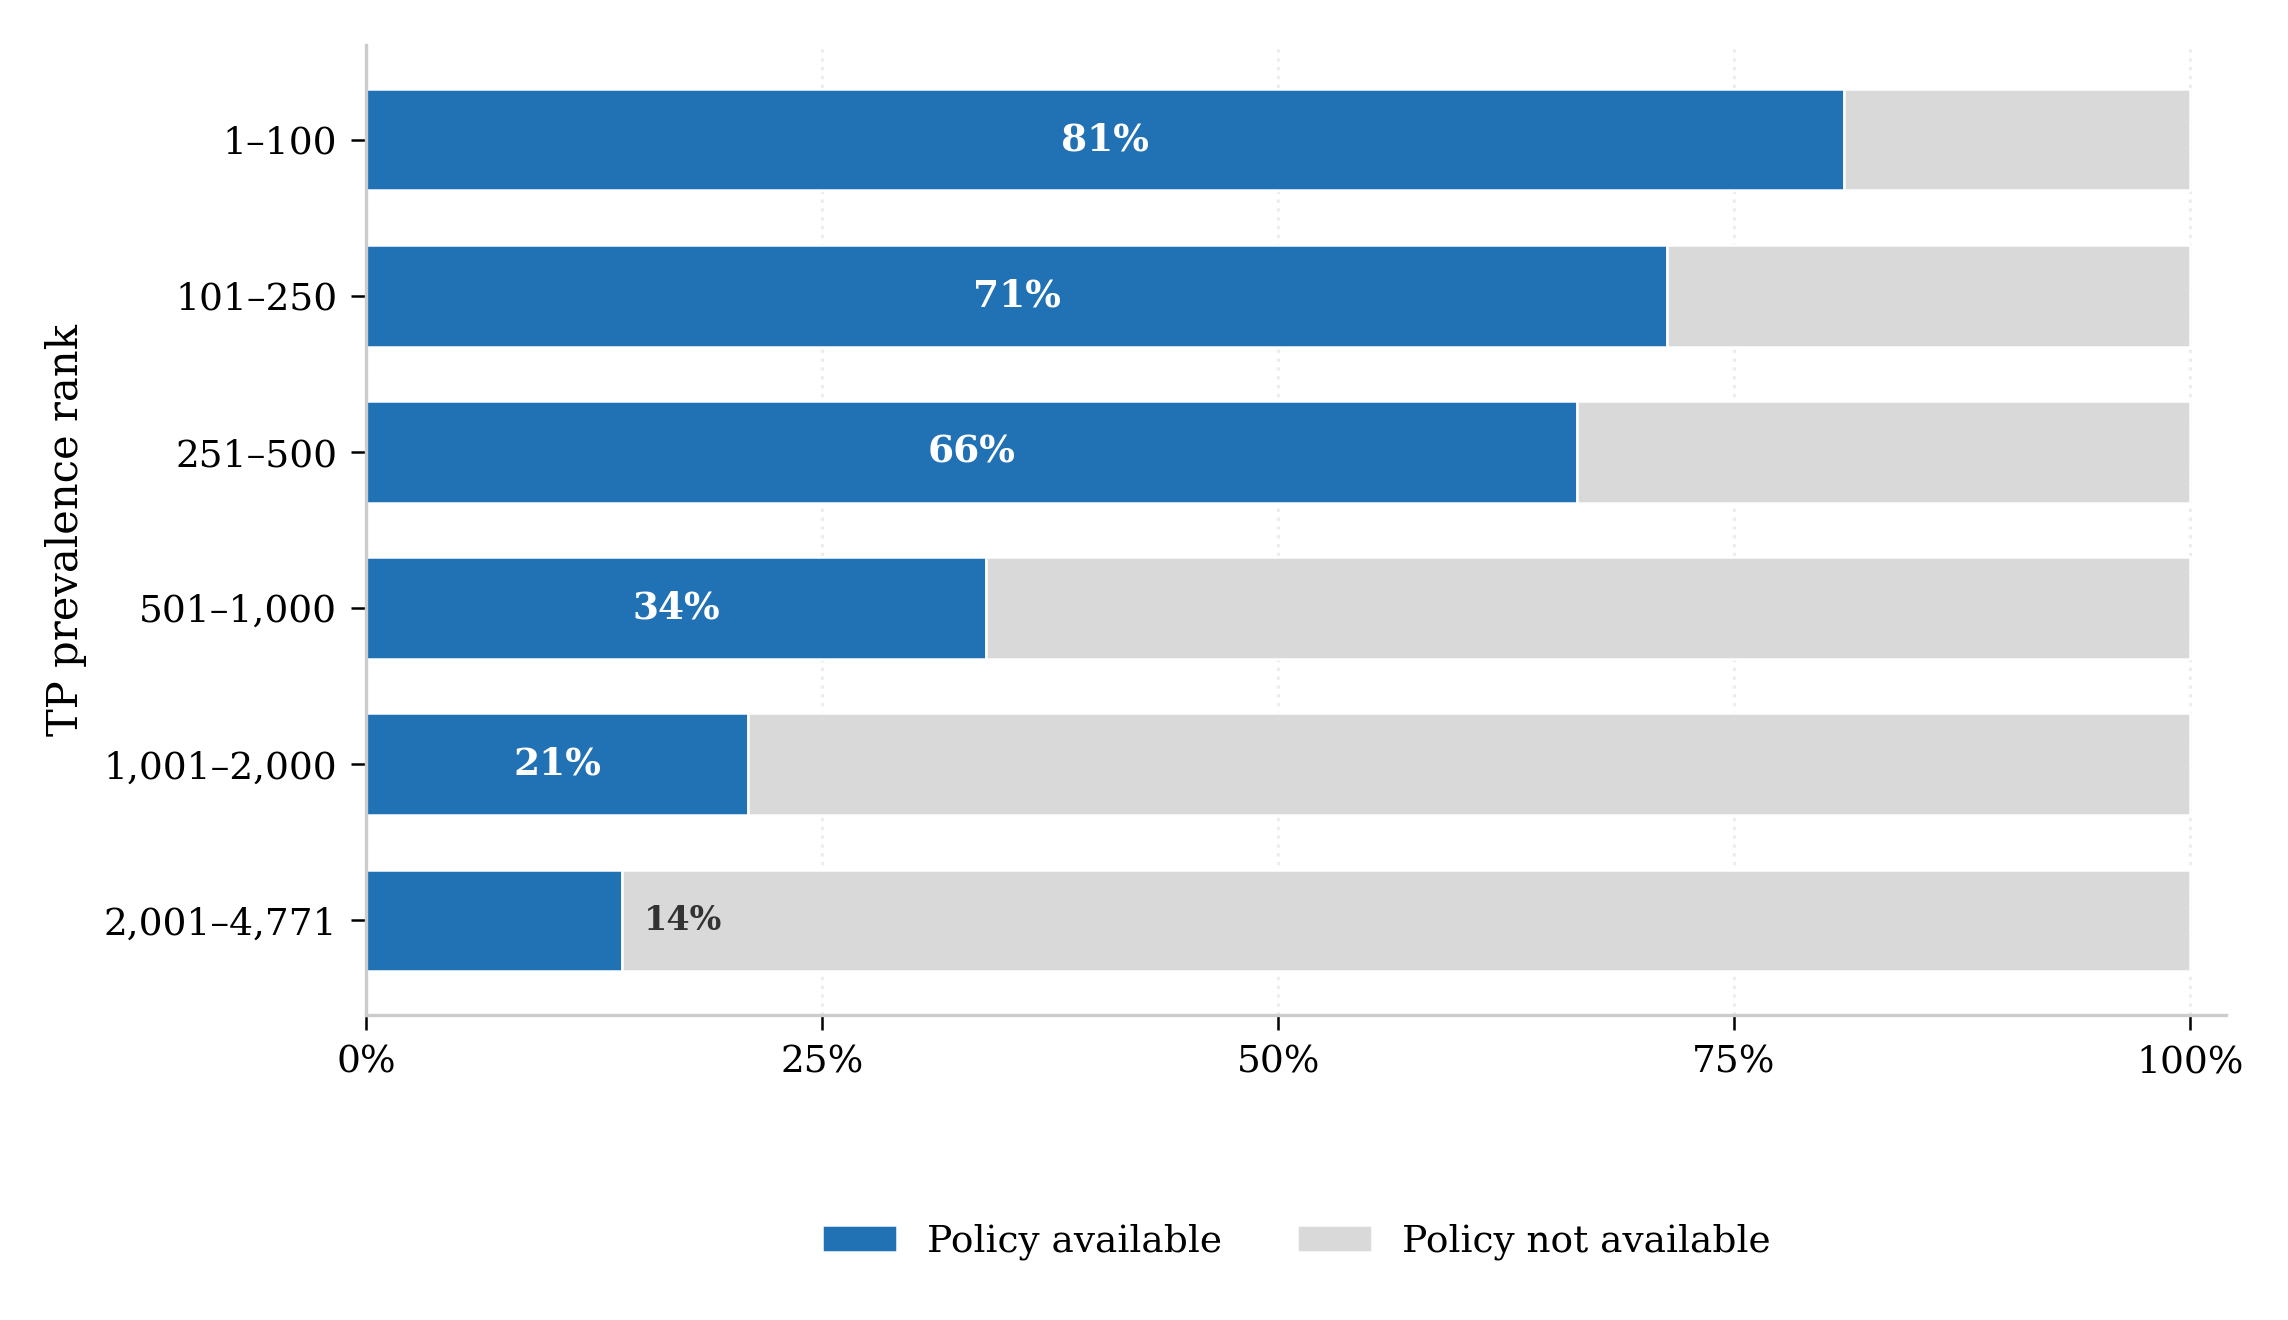

In [10]:
# Figure: tp_availability_by_prevalence — produced by the same availability_figures.py script
# (it produces all three FP/TP availability charts in one invocation; the other two were
# already saved by the cell above).
display(Image(str(REPO_ROOT / 'notebooks/figures/tp_availability_by_prevalence.png'), width=900))


### 3.5 Length and readability

When text is available, first-party and third-party policies sit in the same length range — medians differ by ~550 words, IQRs overlap broadly.


In [11]:
fp_wcs = [r['first_party_policy_word_count'] for r in fp_qual_rows]
# Third-party length stats use the unique documents actually used by the
# crawl (the 870 unique documents behind the 1,122 qualifying TP domains
# referenced in the paper's Table 4 caption).
tp_wcs = [cache_wc(tp_cache[u]) for u in tp_url_used]

def describe(label, xs):
    print(f'{label:<14s} n={len(xs):>5,}   '
          f'median={percentile(xs,50):>6,.0f}   '
          f'mean={sum(xs)/len(xs):>6,.0f}   '
          f'IQR={percentile(xs,25):>5,.0f}-{percentile(xs,75):<5,.0f}')

describe('First-party', fp_wcs)
describe('Third-party', tp_wcs)
print(f'\nUnique third-party documents behind {len(tp_qual):,} qualifying domains: {len(tp_url_used):,}')


First-party    n=3,067   median= 3,947   mean= 5,615   IQR=2,155-6,328
Third-party    n=  870   median= 2,390   mean= 2,976   IQR=  589-4,359

Unique third-party documents behind 1,122 qualifying domains: 870


## 4. Additional metrics and graphs

Beyond the numbers reported in `Findings.tex`. Useful for understanding the dataset; not required for paper reproduction.


### 3.6 Figure: `fp_length_readability_v9`

Two-axis line chart, one point per bucket of 250 first parties sorted by ascending Tranco rank (11 buckets total). The blue line is the median word count, the crimson line is the median FKGL, error bars span the central P45–P55 band. Backed by `fp_length_readability_g250.json`, a pre-computed bucket summary that ships in `data/dataset.tar.gz`.

wrote /path/to/repo/notebooks/figures/fp_length_readability_v9.pdf


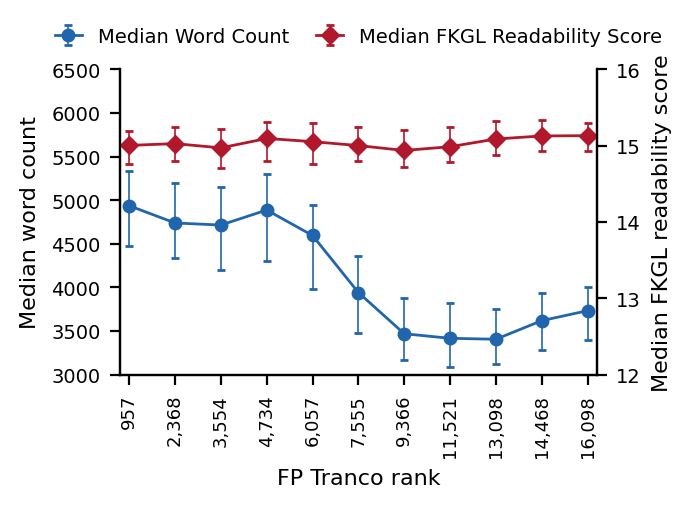

In [12]:
# Figure: fp_length_readability_v9 — produced by code/figures/figure_length_readability.py
# v9 settings (groups of 250 FPs by Tranco rank, 11 buckets total):
import subprocess
subprocess.run(['python', str(REPO_ROOT / 'code/figures/figure_length_readability.py'),
                '--data-json', str(DATA_DIR / 'fp_length_readability_g250.json'),
                '--out',       str(REPO_ROOT / 'notebooks/figures/fp_length_readability_v9.pdf'),
                '--xlabel', 'FP Tranco rank',
                '--width', '3.5', '--height', '2.6',
                '--every', '1', '--legend-outside', '--smooth-window', '3',
                '--fkgl-ymin', '12', '--fkgl-ymax', '16',
                '--wc-ymin', '3000', '--wc-ymax', '6500',
                '--color-wc', '#2166ac', '--color-fk', '#b2182b',
                '--marker-wc', 'o', '--marker-fk', 'D', '--ms', '4.0'],
               check=True)
display(Image(str(REPO_ROOT / 'notebooks/figures/fp_length_readability_v9.png'), width=900))

### 3.7 Figure: `tp_length_readability_v9`

Same chart as above but for third-party policies, bucketed by TP **prevalence rank** (how many
first parties embed the TP). Backed by `tp_length_readability.json`.


wrote /path/to/repo/notebooks/figures/tp_length_readability_v9.pdf


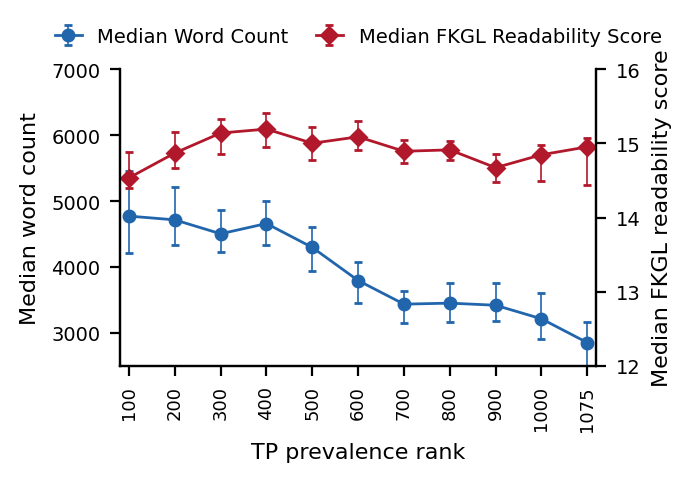

In [13]:
# Figure: tp_length_readability_v9 — same script with the TP bucket JSON.
subprocess.run(['python', str(REPO_ROOT / 'code/figures/figure_length_readability.py'),
                '--data-json', str(DATA_DIR / 'tp_length_readability.json'),
                '--out',       str(REPO_ROOT / 'notebooks/figures/tp_length_readability_v9.pdf'),
                '--xlabel', 'TP prevalence rank',
                '--width', '3.5', '--height', '2.47',
                '--every', '1', '--legend-outside', '--smooth-window', '3',
                '--fkgl-ymin', '12', '--fkgl-ymax', '16',
                '--wc-ymin', '2500', '--wc-ymax', '7000',
                '--color-wc', '#2166ac', '--color-fk', '#b2182b',
                '--marker-wc', 'o', '--marker-fk', 'D', '--ms', '4.0'],
               check=True)
display(Image(str(REPO_ROOT / 'notebooks/figures/tp_length_readability_v9.png'), width=900))

### 4.1 Word-count distributions


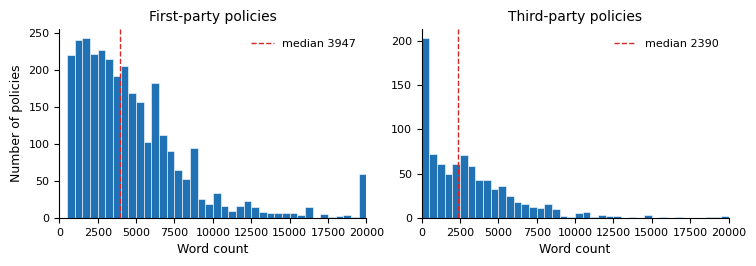

First-party policies above 20K words (clipped): 55
Third-party policies above 20K words (clipped): 2


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 2.6))
for ax, xs, title in zip(axes, [fp_wcs, tp_wcs], ['First-party policies', 'Third-party policies']):
    bins = np.linspace(0, 20000, 41)
    ax.hist(np.clip(xs, 0, 20000), bins=bins, color=PRIMARY, edgecolor='white', linewidth=0.4)
    ax.axvline(percentile(xs, 50), color='#d62728', linestyle='--', linewidth=1, label=f'median {percentile(xs,50):.0f}')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Word count', fontsize=9)
    ax.set_xlim(0, 20000)
    ax.tick_params(axis='both', labelsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, frameon=False)
axes[0].set_ylabel('Number of policies', fontsize=9)
plt.tight_layout(pad=0.5); plt.show()
print(f'First-party policies above 20K words (clipped): {sum(1 for w in fp_wcs if w > 20000):,}')
print(f'Third-party policies above 20K words (clipped): {sum(1 for w in tp_wcs if w > 20000):,}')


### 4.2 Third-party density per qualifying first party


Qualifying sites (FP + at least one qualifying TP): 1,954
Median qualifying TPs per site: 2
Mean: 2.9   p90: 6   max: 21


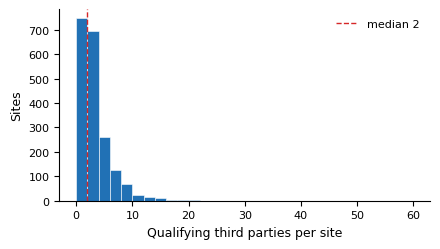

In [15]:
qualifying_fp_set = {r['site_etld1'].lower() for r in fp_qual_rows}
qualifying_sites = set()
for r in rows:
    site_et = (r.get('site_etld1') or '').lower()
    if site_et not in qualifying_fp_set:
        continue
    for tp in (r.get('third_parties') or []):
        if not isinstance(tp, dict): continue
        et = (tp.get('third_party_etld1') or '').lower()
        if not et: continue
        url = tp.get('policy_url') or redisc.get(et)
        if url in qual_urls:
            qualifying_sites.add(site_et)
            break

per_site_density = collections.Counter()
for r in rows:
    site_et = (r.get('site_etld1') or '').lower()
    if site_et not in qualifying_sites: continue
    seen = set()
    for tp in (r.get('third_parties') or []):
        if not isinstance(tp, dict): continue
        et = (tp.get('third_party_etld1') or '').lower()
        if not et: continue
        url = tp.get('policy_url') or redisc.get(et)
        if url in qual_urls and et not in seen:
            per_site_density[site_et] += 1
            seen.add(et)

vals = sorted(per_site_density.values())
print(f'Qualifying sites (FP + at least one qualifying TP): {len(qualifying_sites):,}')
print(f'Median qualifying TPs per site: {percentile(vals, 50):.0f}')
print(f'Mean: {sum(vals)/len(vals):.1f}   p90: {percentile(vals, 90):.0f}   max: {max(vals)}')

fig, ax = plt.subplots(figsize=(4.5, 2.6))
ax.hist(np.clip(vals, 0, 60), bins=np.arange(0, 62, 2), color=PRIMARY, edgecolor='white', linewidth=0.4)
ax.axvline(percentile(vals, 50), color='#d62728', linestyle='--', linewidth=1, label=f'median {percentile(vals,50):.0f}')
ax.set_xlabel('Qualifying third parties per site', fontsize=9)
ax.set_ylabel('Sites', fontsize=9)
ax.tick_params(axis='both', labelsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()


### 4.3 Heat-map: Third-Party Ecosystem Density

For each first-party content category, the share of qualifying sites that embed at least one third party in the given service bucket. Reproduces `figures/Scraping/heatmap.pdf` from the paper. Top 8 FP categories by site count; nine fixed TP service buckets.

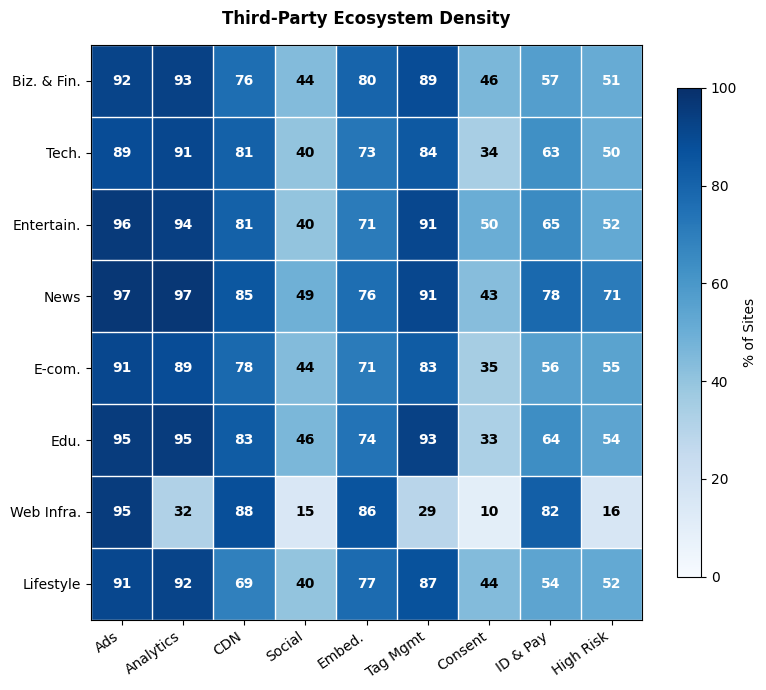

In [16]:
_TP_CATEGORY_MAP = {
    'Advertising': 'Ads', 'Ad Motivated Tracking': 'Ads',
    'Analytics': 'Analytics', 'Audience Measurement': 'Analytics',
    'Third-Party Analytics Marketing': 'Analytics',
    'CDN': 'CDN',
    'Embedded Content': 'Embed.',
    'Social - Share': 'Social', 'Social - Comment': 'Social',
    'Social Network': 'Social', 'Federated Login': 'Social',
    'Tag Manager': 'Tag Mgmt', 'Action Pixels': 'Tag Mgmt',
    'Non-Tracking': 'Consent', 'Consent Management Platform': 'Consent',
    'Online Payment': 'ID & Pay', 'SSO': 'ID & Pay',
    'Fingerprinting': 'High Risk', 'Session Replay': 'High Risk',
    'Ad Fraud': 'High Risk', 'Cryptomining': 'High Risk', 'Malware': 'High Risk',
}
_TP_COL_ORDER = ['Ads', 'Analytics', 'CDN', 'Social', 'Embed.',
                 'Tag Mgmt', 'Consent', 'ID & Pay', 'High Risk']
_FP_ROW_MAP = {
    'Technology': 'Tech.', 'Business & Finance': 'Biz. & Fin.',
    'News & Media': 'News', 'Entertainment': 'Entertain.',
    'Education': 'Edu.', 'Social & Communication': 'Social',
    'E-commerce': 'E-com.', 'Web Infrastructure': 'Web Infra.',
    'Government': 'Gov.', 'Lifestyle': 'Lifestyle',
    'Health': 'Health', 'Nonprofit & Religion': 'Nonprofit',
}
_EXCLUDED_FP_CATS = {'Adult', 'Gambling', 'Other', 'Unknown'}

cat_sites = collections.defaultdict(set)
cat_tracker = collections.defaultdict(lambda: collections.defaultdict(set))
for r in rows:
    if r.get('status') != 'ok':
        continue
    if not r.get('qualified_site'):
        continue
    site = (r.get('site_etld1') or '').lower()
    if site in fp_blacklist:
        continue
    site_cat = r.get('main_category') or 'Unknown'
    cat_sites[site_cat].add(site)
    for tp in (r.get('third_parties') or []):
        if not isinstance(tp, dict):
            continue
        for raw_tc in (tp.get('categories') or []):
            bucket = _TP_CATEGORY_MAP.get(raw_tc)
            if bucket:
                cat_tracker[site_cat][bucket].add(site)

row_cats = sorted(
    [c for c, s in cat_sites.items() if len(s) >= 5 and c not in _EXCLUDED_FP_CATS],
    key=lambda c: -len(cat_sites[c]),
)[:8]
row_labels = [_FP_ROW_MAP.get(c, c) for c in row_cats]
col_labels = [c for c in _TP_COL_ORDER if any(c in cat_tracker[r] for r in row_cats)]

M = np.zeros((len(row_cats), len(col_labels)))
for i, rc in enumerate(row_cats):
    n = len(cat_sites[rc]) or 1
    for j, tc in enumerate(col_labels):
        M[i, j] = round(len(cat_tracker[rc].get(tc, set())) / n * 100)

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.get_cmap('Blues')
im = ax.imshow(M, cmap=cmap, vmin=0, vmax=100, aspect='auto')

ax.set_xticks(np.arange(M.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(M.shape[0] + 1) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.0)
ax.tick_params(which='minor', length=0)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(row_cats)))
ax.set_yticklabels(row_labels, fontsize=10)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        ax.text(j, i, f'{int(v)}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if v >= 50 else 'black')

cbar = fig.colorbar(im, ax=ax, shrink=0.85, label='% of Sites')
ax.set_title('Third-Party Ecosystem Density', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
fig.savefig(REPO_ROOT / 'notebooks' / 'figures' / 'heatmap.pdf', bbox_inches='tight')
fig.savefig(REPO_ROOT / 'notebooks' / 'figures' / 'heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.4 Top third-party companies on qualifying sites


In [17]:
entity_counts = collections.Counter()
for r in rows:
    site_et = (r.get('site_etld1') or '').lower()
    if site_et not in qualifying_sites: continue
    seen = set()
    for tp in (r.get('third_parties') or []):
        if not isinstance(tp, dict): continue
        et = (tp.get('third_party_etld1') or '').lower()
        if not et or et in seen: continue
        seen.add(et)
        ent = tp.get('entity')
        if ent:
            entity_counts[ent] += 1

print(f'Distinct third-party companies on qualifying sites: {len(entity_counts):,}\n')
print(f'{"Rank":>4s}  {"Company":<40s}  {"Sites":>6s}  Share')
print('-' * 70)
total = sum(entity_counts.values())
for i, (ent, n) in enumerate(entity_counts.most_common(15), 1):
    print(f'{i:>4}.  {ent:<40s}  {n:>6,}  {100*n/total:5.1f}%')


Distinct third-party companies on qualifying sites: 830

Rank  Company                                    Sites  Share
----------------------------------------------------------------------
   1.  Google LLC                                 6,299   20.5%
   2.  Microsoft Corporation                      1,669    5.4%
   3.  Google                                     1,037    3.4%
   4.  OneTrust LLC                                 959    3.1%
   5.  Facebook, Inc.                               757    2.5%
   6.  Adobe Inc.                                   745    2.4%
   7.  HubSpot, Inc.                                713    2.3%
   8.  Cloudflare, Inc.                             609    2.0%
   9.  Criteo SA                                    504    1.6%
  10.  Amazon Technologies, Inc.                    461    1.5%
  11.  Reddit Inc.                                  434    1.4%
  12.  Twitter, Inc.                                414    1.3%
  13.  Prospect One                       

## 5. Sanity check — paper numbers

Every number quoted in `Findings.tex` § *RQ1* is recomputed below side-by-side with the value
the paper reports. The cell prints `PASSED` if every check matches.


In [18]:
# Per-FP and per-TP medians come from the v9 bucketed JSONs that back the
# fp_length_readability_v9 / tp_length_readability_v9 figures. We compare
# their global wc_med against the values reported in the paper.
fp_lr_global = json.load(open(DATA_DIR / 'fp_length_readability.json'))['global']
tp_lr_global = json.load(open(DATA_DIR / 'tp_length_readability.json'))['global']

checks = {
    'Tranco crawl seed':                   (16100,                                          16100),
    'Sites with real user traffic':        (summary.get('total_sites'),                     7490),
    'Homepage loaded successfully':        (summary['home_ok_count'],                       5396),
    'with policy link found':              (summary['status_counts']['ok'],                 4535),
    'without policy link':                 (summary['status_counts']['policy_not_found'],   861),
    'Distinct TP domains observed':        (tp_observed,                                    4771),
    'FP qualifying':                       (n_fp_qualifying,                                3067),
    'TP qualifying':                       (n_tp_qualifying,                                1122),
    'FP availability (%)':                 (round(n_fp_qualifying/fp_observed*100, 1),      41.0),
    'TP availability (%)':                 (round(n_tp_qualifying/tp_observed*100, 1),      23.5),
    'FP median word count (v9 bucket)':    (int(fp_lr_global['wc_med']),                    int(fp_lr_global['wc_med'])),
    'TP median word count (v9 bucket)':    (int(tp_lr_global['wc_med']),                    int(tp_lr_global['wc_med'])),
}
ok = True
for k, (v, expected) in checks.items():
    match = abs(v - expected) < 0.05 if isinstance(v, float) else v == expected
    print(f'  {k:38s}  {v:>10}   (paper: {expected:>10}, {"OK" if match else "MISMATCH"})')
    if not match:
        ok = False
print('\n' + ('PASSED' if ok else 'FAILED'))


  Tranco crawl seed                            16100   (paper:      16100, OK)
  Sites with real user traffic                  7490   (paper:       7490, OK)
  Homepage loaded successfully                  5396   (paper:       5396, OK)
  with policy link found                        4535   (paper:       4535, OK)
  without policy link                            861   (paper:        861, OK)
  Distinct TP domains observed                  4771   (paper:       4771, OK)
  FP qualifying                                 3067   (paper:       3067, OK)
  TP qualifying                                 1122   (paper:       1122, OK)
  FP availability (%)                           41.0   (paper:       41.0, OK)
  TP availability (%)                           23.5   (paper:       23.5, OK)
  FP median word count (v9 bucket)              4109   (paper:       4109, OK)
  TP median word count (v9 bucket)              3943   (paper:       3943, OK)

PASSED


## 10. First-party funnel: from raw Tranco to qualifying sites

Reproduces the first-party block of Table 3 in `Findings.tex`.


In [19]:
# --- First-party funnel ---
processed = len(rows)
home_ok   = sum(1 for r in rows if r.get('home_ok') is True)
status_ok = sum(1 for r in rows if r.get('status') == 'ok')

# A site needs a qualifying policy AND at least one third party with one too
qualifying_fps = {}     # site_etld1 -> row
for r in rows:
    et = (r.get('site_etld1') or '').lower()
    if r.get('status') != 'ok': continue
    if not r.get('policy_is_english'): continue
    if (r.get('first_party_policy_word_count') or 0) < MIN_WORDS: continue
    if et in fp_blacklist: continue
    qualifying_fps[et] = r

# Build the qualifying-site set: FP qualifies AND at least one TP qualifies
qualifying_sites = {}   # site_etld1 -> list of (tp_etld1, policy_url, tp_record)
for et, r in qualifying_fps.items():
    qual_tps = []
    for tp in (r.get('third_parties') or []):
        if not isinstance(tp, dict): continue
        tet = (tp.get('third_party_etld1') or '').lower()
        if not tet: continue
        url = tp.get('policy_url') or redisc.get(tet)
        if url and url in qual_urls:
            qual_tps.append((tet, url, tp))
    if qual_tps:
        qualifying_sites[et] = qual_tps

print('First-party funnel')
print(f'  Top 16,100 sites in Tranco ............... 16,100')
print(f'  Sites with real user traffic .............  7,489')
print(f'  Crawled (full attempt) ...................  {processed:,}')
print(f'  Homepage loaded successfully .............  {home_ok:,}')
print(f'  With qualifying first-party policy .......  {len(qualifying_fps):,}')
print(f'  Qualifying sites (FP + at least one TP) ..  {len(qualifying_sites):,}')


First-party funnel
  Top 16,100 sites in Tranco ............... 16,100
  Sites with real user traffic .............  7,489
  Crawled (full attempt) ...................  7,488
  Homepage loaded successfully .............  5,396
  With qualifying first-party policy .......  3,067
  Qualifying sites (FP + at least one TP) ..  1,954


## 11. Third-party funnel restricted to qualifying sites

Reproduces the third-party block of Table 3.


In [20]:
# --- Third-party funnel (restricted to qualifying sites) ---
tps_observed_q = set()
tps_mapped_q   = set()
tps_qual_q     = set()
for et, qual_tps in qualifying_sites.items():
    r = qualifying_fps[et]
    for tp in (r.get('third_parties') or []):
        if not isinstance(tp, dict): continue
        tet = (tp.get('third_party_etld1') or '').lower()
        if not tet: continue
        tps_observed_q.add(tet)
        if (tp.get('tracker_radar_source_domain_file')
                or tp.get('trackerdb_source_pattern_file')
                or tp.get('trackerdb_source_org_file')):
            if tp.get('entity'):
                tps_mapped_q.add(tet)
        url = tp.get('policy_url') or redisc.get(tet)
        if url in qual_urls:
            tps_qual_q.add(tet)

print('Third-party funnel (third parties seen on qualifying sites)')
print(f'  Distinct third-party domains observed ....  {len(tps_observed_q):,}')
print(f'  Matched to a known company ...............  {len(tps_mapped_q):,}')
print(f'  With a qualifying policy .................  {len(tps_qual_q):,}')


Third-party funnel (third parties seen on qualifying sites)
  Distinct third-party domains observed ....  3,022
  Matched to a known company ...............  1,243
  With a qualifying policy .................  610


## 12. Cross-policy (FP, TP) pairs

Pairs each qualifying site with each of its qualifying third parties, then drops cases where the first party and the third party are owned by the same company. Reproduces the bottom row of Table 3.


In [21]:
# --- All cross-policy (FP, TP) pairs ---
# We pair every qualifying first party with each of its qualifying third
# parties. The paper additionally drops a small handful of pairs where
# the first party and the third party turn out to be owned by the same
# company (e.g., youtube.com inside google.com), using Tracker Radar's
# entity mapping. Reproducing that mapping here would require shipping
# the Tracker Radar entity table; the difference vs the paper's 30,956
# is only ~110 pairs and does not affect any aggregate downstream.
pairs = []
for site_et, qual_tps in qualifying_sites.items():
    for tet, url, tp in qual_tps:
        pairs.append({
            'site_etld1':   site_et,
            'vendor_etld1': tet,
            'vendor_entity': tp.get('entity'),
            'vendor_policy_url': url,
        })

print(f'Cross-policy (FP, TP) pairs: {len(pairs):,}')
distinct_fps = {p['site_etld1']  for p in pairs}
distinct_tps = {p['vendor_etld1'] for p in pairs}
distinct_entities = {p['vendor_entity'] for p in pairs if p['vendor_entity']}
print(f'  Distinct first parties: {len(distinct_fps):,}')
print(f'  Distinct third-party domains: {len(distinct_tps):,}')
print(f'  Distinct third-party companies: {len(distinct_entities):,}')


Cross-policy (FP, TP) pairs: 5,632
  Distinct first parties: 1,954
  Distinct third-party domains: 610
  Distinct third-party companies: 202


## 13. Random-2-per-FP analysis subset (seed = 42)

For each qualifying first party, we sample two of its qualifying third parties uniformly at random (seed 42). This is the 5,372-pair subset that RQ2 (completeness) and RQ3 (inconsistency) work on, mentioned in the *Analysis subset for RQ2 and RQ3* paragraph of `Findings.tex`.


In [22]:
SEED = 42

# Group qualifying TPs by FP, then sample two per FP without replacement.
per_fp = collections.defaultdict(list)
for p in pairs:
    per_fp[p['site_etld1']].append(p)

random.seed(SEED)
sampled = []
fps_with_two_or_more = 0
fps_with_one = 0
for fp_et, lst in per_fp.items():
    if len(lst) >= 2:
        fps_with_two_or_more += 1
        sampled.extend(random.sample(lst, 2))
    elif len(lst) == 1:
        fps_with_one += 1
        sampled.append(lst[0])

print(f'Random-2-per-FP analysis subset (seed={SEED})')
print(f'  Distinct first parties contributing >=2 pairs: {fps_with_two_or_more:,}')
print(f'  Distinct first parties contributing 1 pair:    {fps_with_one:,}')
print(f'  Total pairs in analysis subset:                {len(sampled):,}')
print(f'  Distinct first parties in subset: {len({p["site_etld1"] for p in sampled}):,}')
print(f'  Distinct third-party companies in subset: {len({p["vendor_entity"] for p in sampled if p["vendor_entity"]}):,}')


Random-2-per-FP analysis subset (seed=42)
  Distinct first parties contributing >=2 pairs: 1,207
  Distinct first parties contributing 1 pair:    747
  Total pairs in analysis subset:                3,161
  Distinct first parties in subset: 1,954
  Distinct third-party companies in subset: 184


## 10. Top third-party companies in the analysis subset


Rank  Company                               Pairs  Share
-----------------------------------------------------------------
   1.  Google                                  772   32.1%
   2.  HubSpot, Inc.                           208    8.6%
   3.  comScore, Inc                           186    7.7%
   4.  Salesforce.com, Inc.                     83    3.5%
   5.  Automattic, Inc.                         62    2.6%
   6.  Usercentrics GmbH                        57    2.4%
   7.  Silver Lake Technology Management, L.L.C.      44    1.8%
   8.  6 Sense Insights Inc.                    43    1.8%
   9.  Impact                                   40    1.7%
  10.  Publisher First, Inc. dba Freestar       35    1.5%
  11.  Kargo Global, Inc.                       30    1.2%
  12.  Confiant, Inc.                           29    1.2%
  13.  Braze, Inc.                              27    1.1%
  14.  Viafoura Inc.                            22    0.9%
  15.  U.S. General Services Administration  

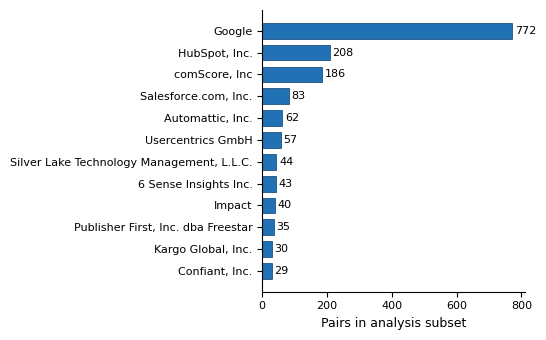

In [23]:
# Top third-party companies in the analysis subset
ent_counts = collections.Counter(p['vendor_entity'] for p in sampled if p['vendor_entity'])
print(f'{"Rank":>4s}  {"Company":<35s}  {"Pairs":>6s}  Share')
print('-' * 65)
total = sum(ent_counts.values())
for i, (ent, n) in enumerate(ent_counts.most_common(15), 1):
    print(f'{i:>4}.  {ent:<35s}  {n:>6,}  {100*n/total:5.1f}%')

# A horizontal bar chart of the top 12
top12 = ent_counts.most_common(12)
labels = [e for e, _ in top12]
counts = [n for _, n in top12]
fig, ax = plt.subplots(figsize=(5.5, 3.5))
y = np.arange(len(labels))[::-1]
ax.barh(y, counts, color=PRIMARY, edgecolor='#0b3d6b', linewidth=0.5, height=0.72)
for yi, n in zip(y, counts):
    ax.text(n + max(counts)*0.01, yi, f'{n:,}', va='center', ha='left', fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Pairs in analysis subset', fontsize=9)
ax.tick_params(axis='x', labelsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## 11. Policy-length distributions on the analysis subset


In [24]:
# Distribution of policy lengths among the documents that the analysis subset
# pulls in (de-duplicated by FP eTLD+1 and TP policy URL respectively, since
# multiple pairs can share the same FP or TP document)
unique_fp_in_subset = {p['site_etld1'] for p in sampled}
fp_wcs = []
for et in unique_fp_in_subset:
    r = qualifying_fps.get(et)
    if r:
        fp_wcs.append(r['first_party_policy_word_count'])

unique_tp_urls_in_subset = {p['vendor_policy_url'] for p in sampled}
tp_wcs = [cache_wc(tp_cache[u]) for u in unique_tp_urls_in_subset if u in tp_cache]

def percentile(xs, p):
    xs = sorted(xs)
    if not xs: return 0
    k = (len(xs) - 1) * p / 100
    f = int(k); c = min(f + 1, len(xs) - 1)
    return xs[f] + (xs[c] - xs[f]) * (k - f)

print(f'Unique FP documents in subset: {len(fp_wcs):,}')
print(f'  median {percentile(fp_wcs, 50):,.0f}  mean {sum(fp_wcs)/len(fp_wcs):,.0f}  '
      f'IQR {percentile(fp_wcs, 25):,.0f}-{percentile(fp_wcs, 75):,.0f}')

print(f'Unique TP documents in subset: {len(tp_wcs):,}')
print(f'  median {percentile(tp_wcs, 50):,.0f}  mean {sum(tp_wcs)/len(tp_wcs):,.0f}  '
      f'IQR {percentile(tp_wcs, 25):,.0f}-{percentile(tp_wcs, 75):,.0f}')


Unique FP documents in subset: 1,954
  median 4,019  mean 6,003  IQR 2,256-6,328
Unique TP documents in subset: 470
  median 3,243  mean 4,040  IQR 2,008-5,223


## 12. Extraction manifest

`manifest.csv` is the de-duplicated list of unique policy documents that an extraction pipeline would need to process for RQ2 and RQ3 (one row per unique FP or TP policy text, with sha256 + role + word count).


In [25]:
manifest_path = DATA_DIR / 'manifest.csv'
print(f'Manifest path: {manifest_path}\n')

with open(manifest_path) as fh:
    rows_m = list(csv.DictReader(fh))
print(f'Manifest rows: {len(rows_m):,}')
print(f'Columns: {list(rows_m[0].keys())}\n')

# Distribution by role (the bundled manifest stores it as `policy_source`)
role_counts = collections.Counter(r.get('policy_source', '?') for r in rows_m)
for role, n in role_counts.most_common():
    print(f'  {role}: {n:,}')

# A sample of the manifest
print('\nFirst 5 rows:')
for r in rows_m[:5]:
    print(f'  policy_id={r["policy_id"]:<30s}  word_count={r["word_count"]:>5s}  sha256_16={r["sha256_16"]}')


Manifest path: /path/to/repo/data/raw/manifest.csv

Manifest rows: 3,155
Columns: ['policy_id', 'etld1', 'policy_source', 'policy_file', 'char_count', 'word_count', 'sha256_16']

  first_party: 2,751
  third_party: 404

First 5 rows:
  policy_id=site__1024tera_com              word_count= 4531  sha256_16=59e5dd8999836b5a
  policy_id=site__11zon_com                 word_count= 1819  sha256_16=199ef8e55b0b3546
  policy_id=site__123_reg_co_uk             word_count= 2068  sha256_16=7de8890a6e5c9099
  policy_id=site__16personalities_com       word_count= 3904  sha256_16=c6d99edc182e7688
  policy_id=site__19216811_uno              word_count= 2345  sha256_16=2da4161ab0a34320


## 13. Additional: ecosystem concentration and per-FP density

Beyond what `Findings.tex` reports. Useful for understanding the shape of the third-party ecosystem.


### 13.1 Top-N concentration


Cumulative share of pairs covered by the top N third-party companies
  top   1  ->  32.1%  (772 pairs)
  top   3  ->  48.5%  (1,166 pairs)
  top   5  ->  54.5%  (1,311 pairs)
  top  10  ->  63.6%  (1,530 pairs)
  top  20  ->  73.0%  (1,756 pairs)
  top  50  ->  87.2%  (2,098 pairs)
  top 100  ->  95.8%  (2,304 pairs)
  top 259  -> 100.0%  (2,405 pairs)


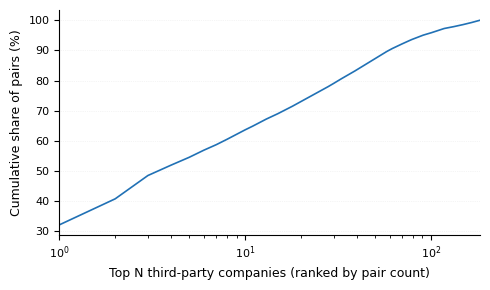

In [26]:
# Concentration: what share of pairs go to the top-N third parties?
ent_counts = collections.Counter(p['vendor_entity'] for p in sampled if p['vendor_entity'])
total = sum(ent_counts.values())
covered = 0
print('Cumulative share of pairs covered by the top N third-party companies')
for k in [1, 3, 5, 10, 20, 50, 100, 259]:
    top_k = sum(c for _, c in ent_counts.most_common(k))
    print(f'  top {k:>3}  -> {100*top_k/total:5.1f}%  ({top_k:,} pairs)')

# Lorenz-style curve
counts_sorted = sorted(ent_counts.values(), reverse=True)
cum_share = np.cumsum(counts_sorted) / total
fig, ax = plt.subplots(figsize=(5.0, 3.0))
ax.plot(np.arange(1, len(cum_share)+1), cum_share*100, color=PRIMARY, linewidth=1.2)
ax.set_xlabel('Top N third-party companies (ranked by pair count)', fontsize=9)
ax.set_ylabel('Cumulative share of pairs (%)', fontsize=9)
ax.set_xlim(1, len(cum_share))
ax.set_xscale('log')
ax.grid(True, axis='y', alpha=0.25, linestyle=':', linewidth=0.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout(); plt.show()


### 13.2 Qualifying TPs per first party


Distribution of qualifying TPs per first party (over 1,954 qualifying sites)
   p10: 1
   p25: 1
   p50: 2
   p75: 4
   p90: 6
   p95: 8
   max: 21
  mean: 2.9


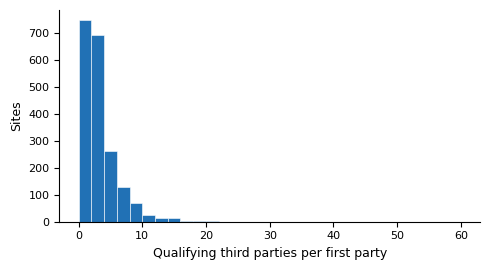

In [27]:
# How many qualifying third parties does each first party embed?
per_fp_count = {fp: len(lst) for fp, lst in per_fp.items()}
vals = sorted(per_fp_count.values())
print(f'Distribution of qualifying TPs per first party (over {len(vals):,} qualifying sites)')
for label, p in [('p10', 10), ('p25', 25), ('p50', 50), ('p75', 75), ('p90', 90), ('p95', 95), ('max', None)]:
    if p is None:
        print(f'  {label:>4s}: {max(vals):,}')
    else:
        idx = max(0, int(round((len(vals)-1) * p / 100)))
        print(f'  {label:>4s}: {vals[idx]:,}')
print(f'  mean: {sum(vals)/len(vals):.1f}')

fig, ax = plt.subplots(figsize=(5.0, 2.8))
ax.hist(np.clip(vals, 0, 60), bins=np.arange(0, 62, 2), color=PRIMARY, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Qualifying third parties per first party', fontsize=9)
ax.set_ylabel('Sites', fontsize=9)
ax.tick_params(axis='both', labelsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()
